# 🧠 Mecanismo de Atenção (*Self-Attention*) dos Transformers: O Guia Visual Definitivo (v2.0)
**Disciplina:** COM170 — Inteligência Artificial na Prática Acadêmica e Profissional  
**Módulo:** Quinzena 02 — Atenção, Contexto e Representação Semântica  
**Público-alvo:** Estudantes visuais, mentes curiosas e aprendizes neurodivergentes (TEA)  

---

### 🌟 Um Recado do seu Professor e Mentor Técnico:
> *"Se você já sentiu frustração ao olhar para fórmulas cheias de símbolos gregos e matrizes abstratas, respire fundo: **você não foi enganado(a) e você pertence a este curso!**  
> Na universidade e na literatura científica, muitas vezes a matemática é apresentada de trás para frente — mostram a equação pronta sem antes mostrar a **história**, a **imagem mental**, as **cores** e o **significado prático** de cada peça.  
> Quando pensamos de forma visual e estruturada, como ocorre no espectro autista (TEA), o cérebro busca **padrões claros, cores, relações espaciais e analogias concretas**. É exatamente isso que vamos construir aqui juntos, passo a passo."*

---

## 🗺️ O Mapa Completo da Nossa Jornada

1. 📜 **A Origem:** Como descobriram essa fórmula? (Do *Telefone Sem Fio* aos Bancos de Dados).
2. 🕵️ **A Grande Metáfora:** A Sala de Investigação e os Crachás de Identificação.
3. 📢 **O que é $Q$ (Query)?** A pergunta que cada palavra faz ao mundo.
4. 🏷️ **O que é $K$ (Key)?** A etiqueta / crachá que cada palavra exibe.
5. 🎒 **O que é $V$ (Value)?** A mochila de significado e conteúdo real da palavra.
6. 🤝 **Por que multiplicamos $Q$ por $K^T$?** O medidor de afinidade e compatibilidade entre palavras.
7. 🌡️ **Por que dividimos por $\sqrt{d_k}$?** O termostato / regulador de volume que evita números explodirem.
8. 🍕 **O que é o $\text{Softmax}$ em profundidade?** Hard-Max vs Soft-Max e a mágica do $e^x$.
9. 🎨 **O que significa o resultado final ($\% \times V$)?** A mistura de tintas que dá o novo sentido à palavra!
10. 📝 **Cálculo no Papel e Lápis:** Um exercício de 3 minutos passo a passo que você pode fazer à mão!


---
## 📜 1. Como Descobriram essa Fórmula "Mágica"?

### O Problema do Passado: "O Telefone Sem Fio" (RNNs e LSTMs)
Antes de 2017, as inteligências artificiais liam textos como uma pessoa lendo palavra por palavra através de um canudinho estreito:
* Elas liam a palavra 1, guardavam na memória.
* Depois liam a palavra 2, misturavam com a 1.
* Depois a palavra 3...
* Quando chegavam na **palavra 50**, o modelo já tinha **esquecido** o que estava escrito na palavra 1! Era exatamente como a brincadeira do **telefone sem fio**: a mensagem ia se distorcendo e se perdendo pelo caminho.

```text
  [Palavra 1] ──► [Palavra 2] ──► [Palavra 3] ──► ... ──► [Palavra 50]
      │               │               │                        │
   (Lê tudo)      (Mistura)       (Começa a esquecer)      (Esqueceu quase tudo! 😵)
```

---

### A Sacada Genial: A Inspiração nos Bancos de Dados (2017)
Em 2017, uma equipe de 8 pesquisadores do Google (*Vaswani et al.*) publicou um artigo histórico chamado:  
📄 **"Attention Is All You Need"** (*Atenção É Tudo O Que Você Precisa*).

Eles pensaram: *"Como os programadores buscam informações em computadores há mais de 40 anos?"*  
Nos bancos de dados e nos dicionários do Python (`dict`), nós usamos o conceito de **Chave e Valor (`Key-Value`)**:

```python
# Em um dicionário comum do Python (Busca Exata / Hard Lookup):
banco_de_dados = {
    "saldo": "R$ 150,00",   # "saldo" é a KEY (Chave), "R$ 150,00" é o VALUE (Valor)
    "nome": "Lucas"        # "nome" é a KEY (Chave), "Lucas" é o VALUE (Valor)
}

# Se você faz uma QUERY (Pergunta):
minha_query = "saldo"
resultado = banco_de_dados[minha_query] # Retorna exatamente o Value: "R$ 150,00"
```

### A Inovação dos Transformers: A Busca Flexível (*Soft Lookup*)
No dicionário do Python, a busca é rígida: ou a palavra bate 100% igual ou dá erro.  
Os criadores do Transformer pensaram:  
> *"E se a gente fizesse uma busca flexível, onde uma palavra não precisa bater 100% com a outra, mas sim **pegar um pouquinho do significado de cada palavra da frase**, proporcional à relevância dela?"*

Foi assim que nasceu a fórmula:
* $Q$ (Query) = O que estou procurando?
* $K$ (Key) = Qual é a chave de cada palavra?
* $V$ (Value) = Qual é a informação guardada em cada palavra?
* $	ext{Softmax}$ = A régua que decide quanto de cada valor devemos pegar!


---
## 📦 Configuração do Ambiente e Ferramentas Visuais

Vamos importar o PyTorch, NumPy e as ferramentas gráficas (`matplotlib` e `seaborn`).


In [ ]:
import math
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração estética dos gráficos
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style="whitegrid", palette="muted")
print("Bibliotecas carregadas com sucesso! Ambiente pronto para visualizações.")


---
## 🕵️ 2. A Grande Metáfora: "A Sala de Investigação de Palavras"

Imagine uma sala onde estão reunidas as palavras de uma frase:

$$\text{["O", "homem", "foi", "ao", "banco", "pagar", "a", "conta"]}$$

A palavra **`"banco"`** está confusa. Ela tem dois sentidos possíveis:
* Sentido 1: *Um assento de madeira no parque.*
* Sentido 2: *Uma instituição financeira onde guardamos dinheiro.*

Para descobrir qual é o seu verdadeiro sentido, cada palavra na sala recebe **três objetos mágicos**:

```text
 ┌─────────────────────────────────────────────────────────────────────────────┐
 │                       OS 3 OBJETOS MÁGICOS DE CADA PALAVRA                  │
 ├─────────────────────────┬─────────────────────────┬─────────────────────────┤
 │     📢 1. QUERY (Q)     │      🏷️ 2. KEY (K)      │     🎒 3. VALUE (V)     │
 │       (A Pergunta)      │       (O Crachá)        │       (A Mochila)       │
 ├─────────────────────────┼─────────────────────────┼─────────────────────────┤
 │ O que esta palavra quer │ O que esta palavra      │ O conteúdo de ideias e  │
 │ saber para entender seu │ anuncia que ela é para  │ detalhes que ela doa se │
 │ contexto atual.         │ as outras palavras.     │ houver afinidade.       │
 └─────────────────────────┴─────────────────────────┴─────────────────────────┘
```

### O Diálogo na Sala:
1. **`"banco"`** pega seu megafone (**$Q$**) e pergunta:  
   *📢 "Quem aqui na sala tem a ver com dinheiro, finanças ou transações?"*
2. Todas as palavras mostram seus crachás (**$K$**):
   * `"homem"` mostra o crachá: *🏷️ "Sou um ser humano"* (Afinidade: Baixa 🥱)
   * `"pagar"` mostra o crachá: *🏷️ "Sou finanças e ação!"* (Afinidade: **ALTÍSSIMA!** 🎯)
   * `"conta"` mostra o crachá: *🏷️ "Sou cobrança financeira!"* (Afinidade: **ALTÍSSIMA!** 🎯)
3. A palavra **`"banco"`** calcula a afinidade e decide:  
   *"Vou prestar **65%** de atenção em `pagar`, **25%** em `conta`, **5%** em mim mesma e **5%** no resto!"*
4. Ela então vai até a mochila (**$V$**) de `"pagar"` e `"conta"` e retira as informações financeiras.
5. **Resultado:** O novo vetor de `"banco"` agora sabe com 100% de certeza que é um **banco financeiro**!


---
## 🎨 3. Visualizando os Vetores $Q$, $K$ e $V$

Vamos criar um exemplo didático com 4 palavras: `["homem", "banco", "pagar", "praça"]`.  

Aqui utilizamos a ordem de características semânticas solicitada:  
$$\text{Características Semânticas: } [\text{Pessoa}, \; \text{Finanças}, \; \text{Ação}, \; \text{Lugar}]$$

* Posição 0: *Pessoa / Ser vivo*
* Posição 1: *Finanças / Dinheiro*
* Posição 2: *Ação / Verbo*
* Posição 3: *Lugar / Localização*


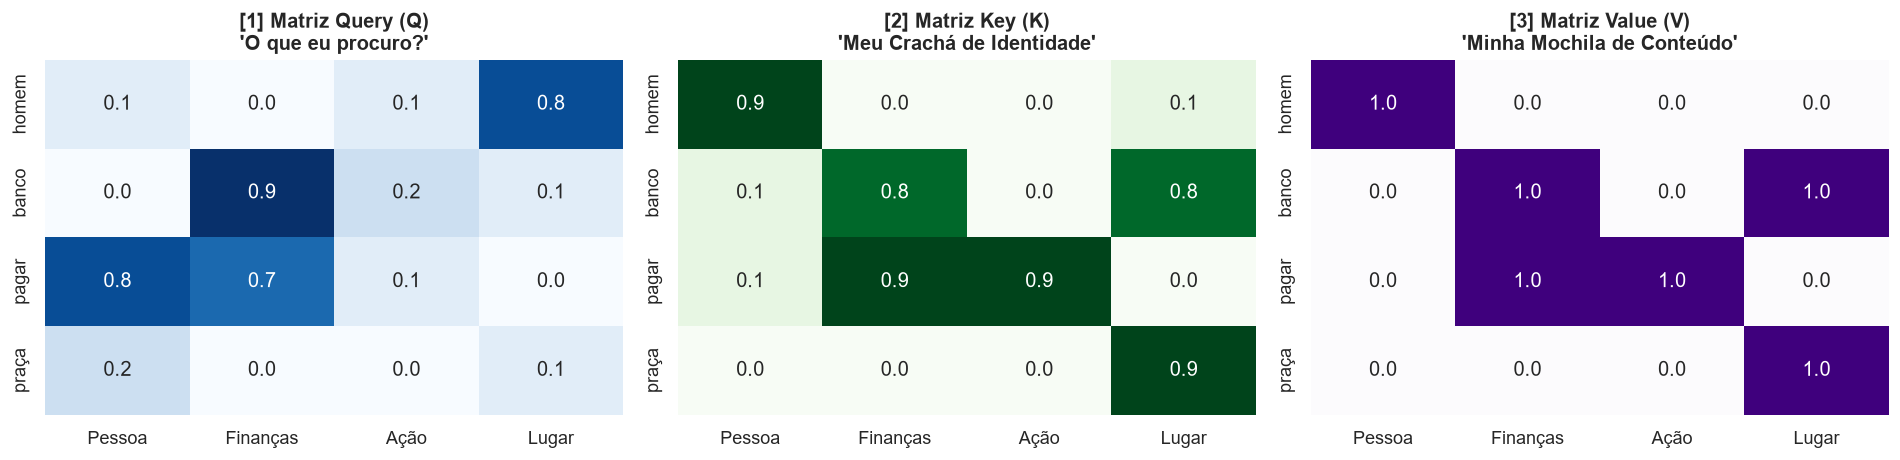

In [3]:
palavras = ["homem", "banco", "pagar", "praça"]
num_palavras = len(palavras)
dim_k = 4 # Dimensão d_k (4 características)

# Ordem dos atributos semânticos: [Pessoa, Finanças, Ação, Lugar]
atributos = ["Pessoa", "Finanças", "Ação", "Lugar"]

# 1. Matriz de Queries Q (O que cada palavra procura?)
matriz_Q = torch.tensor([
    [0.1, 0.0, 0.1, 0.8],  # "homem" procura onde foi (Lugar=0.8) ou o que fez
    [0.0, 0.9, 0.2, 0.1],  # "banco" procura pistas sobre finanças! (Finanças=0.9)
    [0.8, 0.7, 0.1, 0.0],  # "pagar" procura quem paga (Pessoa=0.8) e valor (Finanças=0.7)
    [0.2, 0.0, 0.0, 0.1],  # "praça" procura qualificadores
], dtype=torch.float32)

# 2. Matriz de Keys K (Crachá de identidade de cada palavra)
matriz_K = torch.tensor([
    [0.9, 0.0, 0.0, 0.1],  # "homem" crachá: [Pessoa=0.9]
    [0.1, 0.8, 0.0, 0.8],  # "banco" crachá: [Finanças=0.8, Lugar=0.8]
    [0.1, 0.9, 0.9, 0.0],  # "pagar" crachá: [Finanças=0.9, Ação=0.9]
    [0.0, 0.0, 0.0, 0.9],  # "praça" crachá: [Lugar=0.9]
], dtype=torch.float32)

# 3. Matriz de Values V (Mochila de conteúdo de cada palavra)
matriz_V = torch.tensor([
    [1.0, 0.0, 0.0, 0.0],  # Valor "homem": Conceito biológico humano
    [0.0, 1.0, 0.0, 1.0],  # Valor "banco": Conceito financeiro e estrutural
    [0.0, 1.0, 1.0, 0.0],  # Valor "pagar": Conceito de quitação monetária e ação
    [0.0, 0.0, 0.0, 1.0],  # Valor "praça": Conceito de parque público
], dtype=torch.float32)

fig, eixos = plt.subplots(1, 3, figsize=(16, 4))

sns.heatmap(matriz_Q.numpy(), annot=True, fmt=".1f", cmap="Blues", 
            xticklabels=atributos, yticklabels=palavras, cbar=False, ax=eixos[0])
eixos[0].set_title("[1] Matriz Query (Q)\n'O que eu procuro?'", fontsize=12, fontweight='bold')

sns.heatmap(matriz_K.numpy(), annot=True, fmt=".1f", cmap="Greens", 
            xticklabels=atributos, yticklabels=palavras, cbar=False, ax=eixos[1])
eixos[1].set_title("[2] Matriz Key (K)\n'Meu Crachá de Identidade'", fontsize=12, fontweight='bold')

sns.heatmap(matriz_V.numpy(), annot=True, fmt=".1f", cmap="Purples", 
            xticklabels=atributos, yticklabels=palavras, cbar=False, ax=eixos[2])
eixos[2].set_title("[3] Matriz Value (V)\n'Minha Mochila de Conteúdo'", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


---
## 🤝 4. Passo 1: Por que multiplicamos $Q$ por $K^T$? ($Q \cdot K^T$)

* Multiplicar $Q$ por $K$ calcula o **Produto Escalar (*Dot Product*)**, que é um **Medidor de Afinidade**.
* Como a palavra **`"banco"`** procura *Finanças* ($Q_{\text{banco}}[1] = 0.9$) e **`"pagar"`** anuncia *Finanças* ($K_{\text{pagar}}[1] = 0.9$), a multiplicação entre elas gera a nota mais alta da tabela!
* Usamos $K^T$ (transposta) para girar a matriz e cruzar **todas as palavras contra todas as outras palavras**.


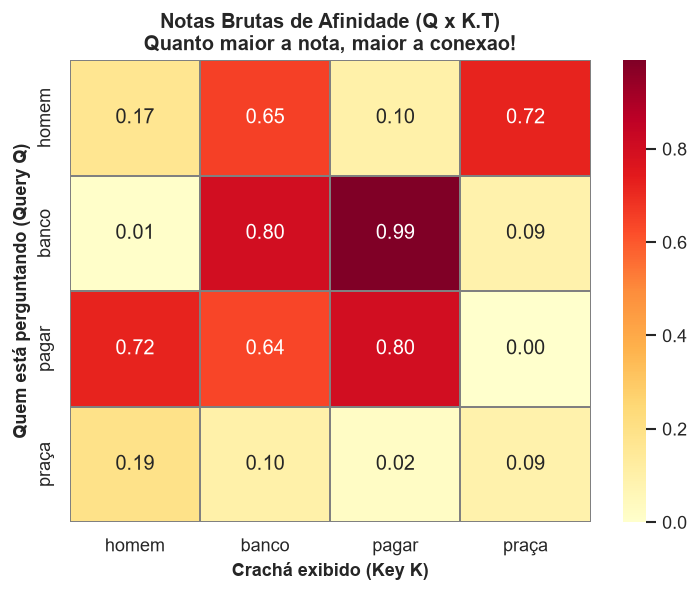

Observe a linha da palavra 'banco':
 • Afinidade de 'banco' com 'homem': 0.01 (baixa)
 • Afinidade de 'banco' com 'banco': 0.80 (média)
 • Afinidade de 'banco' com 'pagar': 0.99 -> (ALTÍSSIMA!)
 • Afinidade de 'banco' com 'praça': 0.09 (baixa)


In [4]:
afinidade_bruta = torch.matmul(matriz_Q, matriz_K.transpose(-2, -1))

plt.figure(figsize=(7, 5))
sns.heatmap(afinidade_bruta.numpy(), annot=True, fmt=".2f", cmap="YlOrRd",
            xticklabels=palavras, yticklabels=palavras, linewidths=1, linecolor='gray')
plt.title("Notas Brutas de Afinidade (Q x K.T)\nQuanto maior a nota, maior a conexao!", fontsize=12, fontweight='bold')
plt.xlabel("Crachá exibido (Key K)", fontsize=11, fontweight='bold')
plt.ylabel("Quem está perguntando (Query Q)", fontsize=11, fontweight='bold')
plt.show()

print("Observe a linha da palavra 'banco':")
print(f" • Afinidade de 'banco' com 'homem': {afinidade_bruta[1, 0]:.2f} (baixa)")
print(f" • Afinidade de 'banco' com 'banco': {afinidade_bruta[1, 1]:.2f} (média)")
print(f" • Afinidade de 'banco' com 'pagar': {afinidade_bruta[1, 2]:.2f} -> (ALTÍSSIMA!)")
print(f" • Afinidade de 'banco' com 'praça': {afinidade_bruta[1, 3]:.2f} (baixa)")


---
## 🌡️ 5. Passo 2: Por que dividimos por $\sqrt{d_k}$? (O Termostato)

* Quando os vetores têm muitas dimensões (ex: 64 no GPT-2), somar dezenas de números gera notas gigantescas ($80, 150, 300$).
* Notas gigantes fariam o Softmax travar e dar 100% para uma palavra e 0% para todas as outras (*saturação*).
* Dividir por $\sqrt{d_k}$ (ex: $\sqrt{4} = 2$) reduz as notas para uma escala equilibrada e calma.


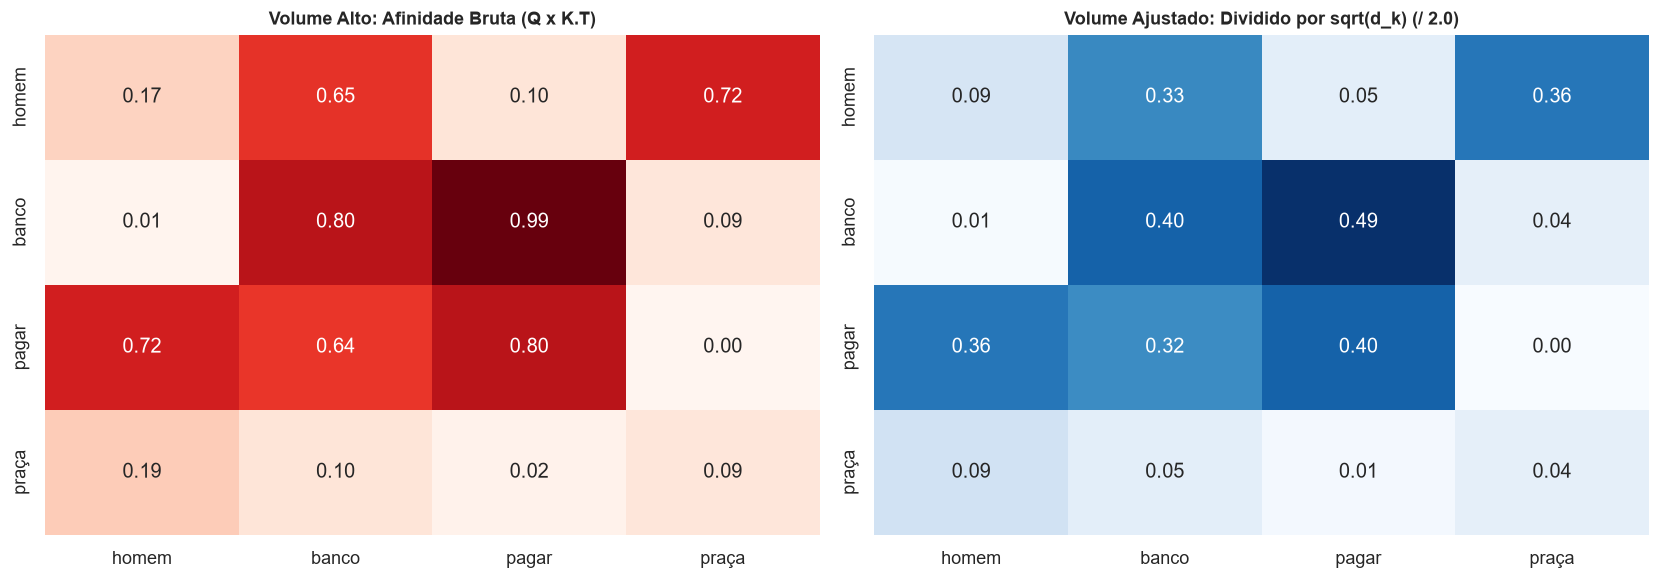

In [5]:
fator_termostato = math.sqrt(dim_k)
notas_escalonadas = afinidade_bruta / fator_termostato

fig, eixos = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(afinidade_bruta.numpy(), annot=True, fmt=".2f", cmap="Reds",
            xticklabels=palavras, yticklabels=palavras, cbar=False, ax=eixos[0])
eixos[0].set_title("Volume Alto: Afinidade Bruta (Q x K.T)", fontsize=11, fontweight='bold')

sns.heatmap(notas_escalonadas.numpy(), annot=True, fmt=".2f", cmap="Blues",
            xticklabels=palavras, yticklabels=palavras, cbar=False, ax=eixos[1])
eixos[1].set_title(f"Volume Ajustado: Dividido por sqrt(d_k) (/ {fator_termostato:.1f})", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 🍕 6. Passo 3: O que é o $\text{Softmax}$ em Profundidade?

### 1. Por que o nome se chama "Soft-max" (*Máximo Suave*)?
Em programação tradicional, se você quer achar o maior elemento de uma lista, você usa o **Hard-Max** (`argmax`):
* `argmax([2.0, 1.0, 8.0])` $\rightarrow$ O item `8.0` ganha $100\%$ e todos os outros ganham $0\%$.
* No Hard-Max, o vencedor leva tudo, como um campeonato onde só existe o campeão e ninguém mais importa.

Mas na linguagem humana, uma palavra quase nunca depende de apenas **uma** outra palavra. Ela precisa de nuances!  
O **Soft-Max** (*Máximo Suave*) cria um **pódio suave**, onde o maior ganha a maior fatia da pizza, mas os outros também recebem fatias proporcionais!

---

### 2. A Matemática Simples do Softmax em 2 Passos:

Dada uma lista de notas qualquer, como $x = [1.0, \; 2.0, \; 3.0]$:

#### Passo A: Aplicar o Exponencial ($e^x$)
Elevamos a constante de Euler ($e \approx 2.718$) a cada número.
* $e^{1.0} \approx 2.72$
* $e^{2.0} \approx 7.39$
* $e^{3.0} \approx 20.09$
* **Por que fazemos isso?** Porque $e^x$ **NUNCA** dá um número negativo! Mesmo que uma nota seja $-10$, $e^{-10} = 0.000045$ (positivo bem pequenininho).

#### Passo B: Somar e Dividir (Normalização)
* Soma total: $2.72 + 7.39 + 20.09 = 30.20$
* Porcentagem 1: $2.72 / 30.20 = 0.09$ ($9\%$)
* Porcentagem 2: $7.39 / 30.20 = 0.24$ ($24\%$)
* Porcentagem 3: $20.09 / 30.20 = 0.67$ ($67\%$)
* **Soma das porcentagens:** $9\% + 24\% + 67\% = 100\%$ ($1.0$).

É exatamente isso que o Softmax faz em cada linha da nossa matriz!


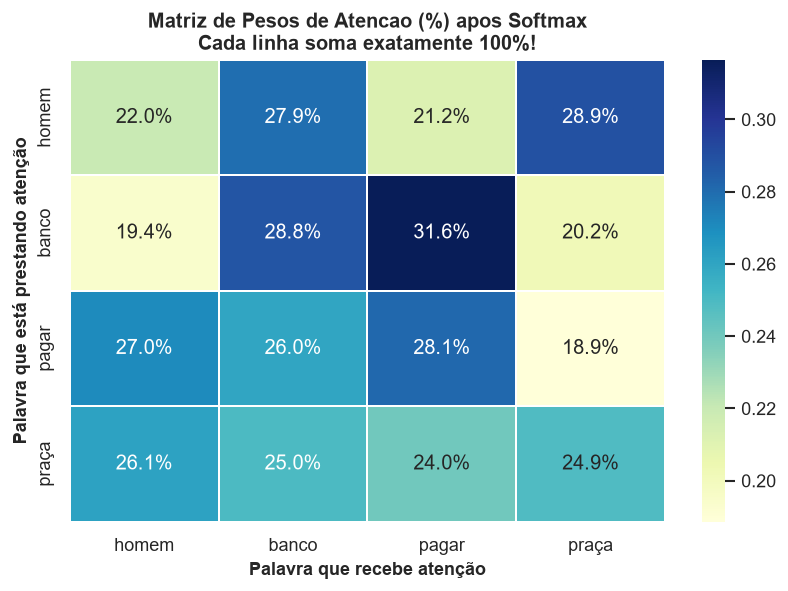

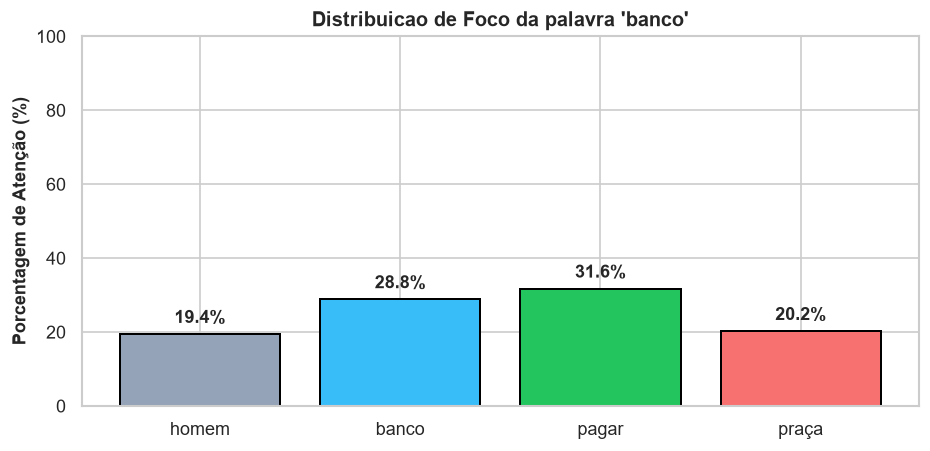

In [6]:
pesos_atencao = F.softmax(notas_escalonadas, dim=-1)

plt.figure(figsize=(8, 5))
sns.heatmap(pesos_atencao.numpy(), annot=True, fmt=".1%", cmap="YlGnBu",
            xticklabels=palavras, yticklabels=palavras, linewidths=1, linecolor='white')
plt.title("Matriz de Pesos de Atencao (%) apos Softmax\nCada linha soma exatamente 100%!", fontsize=12, fontweight='bold')
plt.xlabel("Palavra que recebe atenção", fontsize=11, fontweight='bold')
plt.ylabel("Palavra que está prestando atenção", fontsize=11, fontweight='bold')
plt.show()

# Gráfico de Barras focado exclusivamente na palavra "banco"
plt.figure(figsize=(9, 4))
cores = ['#94a3b8', '#38bdf8', '#22c55e', '#f87171']
pesos_banco = pesos_atencao[1].numpy() * 100

barras = plt.bar(palavras, pesos_banco, color=cores, edgecolor='black', linewidth=1.2)
plt.title("Distribuicao de Foco da palavra 'banco'", fontsize=12, fontweight='bold')
plt.ylabel("Porcentagem de Atenção (%)", fontsize=11, fontweight='bold')
plt.ylim(0, 100)

for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altura + 2,
             f"{altura:.1f}%", ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.show()


---
## 🎨 7. Passo 4: O que significa o resultado final? ($\text{Pesos} \times V$)

Multiplicamos as porcentagens do Softmax pelo conteúdo da mochila ($V$) de cada palavra.  
O resultado é uma **Mistura Ponderada de Tintas**:

$$\text{Novo Sentido de "banco"} = (\text{peso}_{\text{homem}} \times V_{\text{homem}}) + (\text{peso}_{\text{banco}} \times V_{\text{banco}}) + (\text{peso}_{\text{pagar}} \times V_{\text{pagar}}) + (\text{peso}_{\text{praça}} \times V_{\text{praça}})$$

Veja como na nova ordem `[Pessoa, Finanças, Ação, Lugar]` os atributos de **Finanças** e **Ação** ficam destacados:


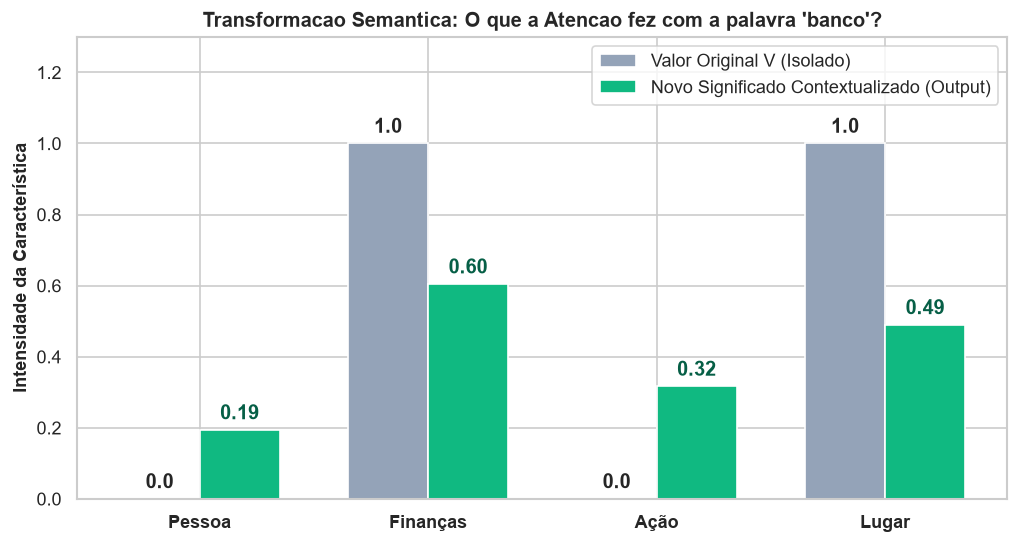

Conclusão Visual:
• Finanças (posição 1): saltou para 0.60 (alta intensidade contextual)
• Ação (posição 2): saltou para 0.32 (absorvida de 'pagar')
• Lugar (posição 3): ficou em 0.49
• O modelo agora compreende o sentido exato do texto!


In [7]:
saida_atencao_final = torch.matmul(pesos_atencao, matriz_V)

vetor_original_banco = matriz_V[1].numpy()
vetor_novo_banco = saida_atencao_final[1].numpy()

posicoes = np.arange(len(atributos))
largura = 0.35

plt.figure(figsize=(10, 5))
plt.bar(posicoes - largura/2, vetor_original_banco, largura, label="Valor Original V (Isolado)", color="#94a3b8")
plt.bar(posicoes + largura/2, vetor_novo_banco, largura, label="Novo Significado Contextualizado (Output)", color="#10b981")

plt.xticks(posicoes, atributos, fontsize=11, fontweight='bold')
plt.ylabel("Intensidade da Característica", fontsize=11, fontweight='bold')
plt.title("Transformacao Semantica: O que a Atencao fez com a palavra 'banco'?", fontsize=12, fontweight='bold')
plt.legend(fontsize=11)
plt.ylim(0, 1.3)

for i in range(len(atributos)):
    plt.text(i - largura/2, vetor_original_banco[i] + 0.03, f"{vetor_original_banco[i]:.1f}", ha='center', fontweight='bold')
    plt.text(i + largura/2, vetor_novo_banco[i] + 0.03, f"{vetor_novo_banco[i]:.2f}", ha='center', fontweight='bold', color="#065f46")
plt.show()

print("Conclusão Visual:")
print(f"• Finanças (posição 1): saltou para {vetor_novo_banco[1]:.2f} (alta intensidade contextual)")
print(f"• Ação (posição 2): saltou para {vetor_novo_banco[2]:.2f} (absorvida de 'pagar')")
print(f"• Lugar (posição 3): ficou em {vetor_novo_banco[3]:.2f}")
print("• O modelo agora compreende o sentido exato do texto!")


---
## 🔬 8. Experimento Lado a Lado: Desambiguação Real

* **Cenário A:** *"O homem foi ao banco pagar a conta"* (Contexto Financeiro 🏦)
* **Cenário B:** *"O homem sentou no banco da praça"* (Contexto de Assento 🌳)


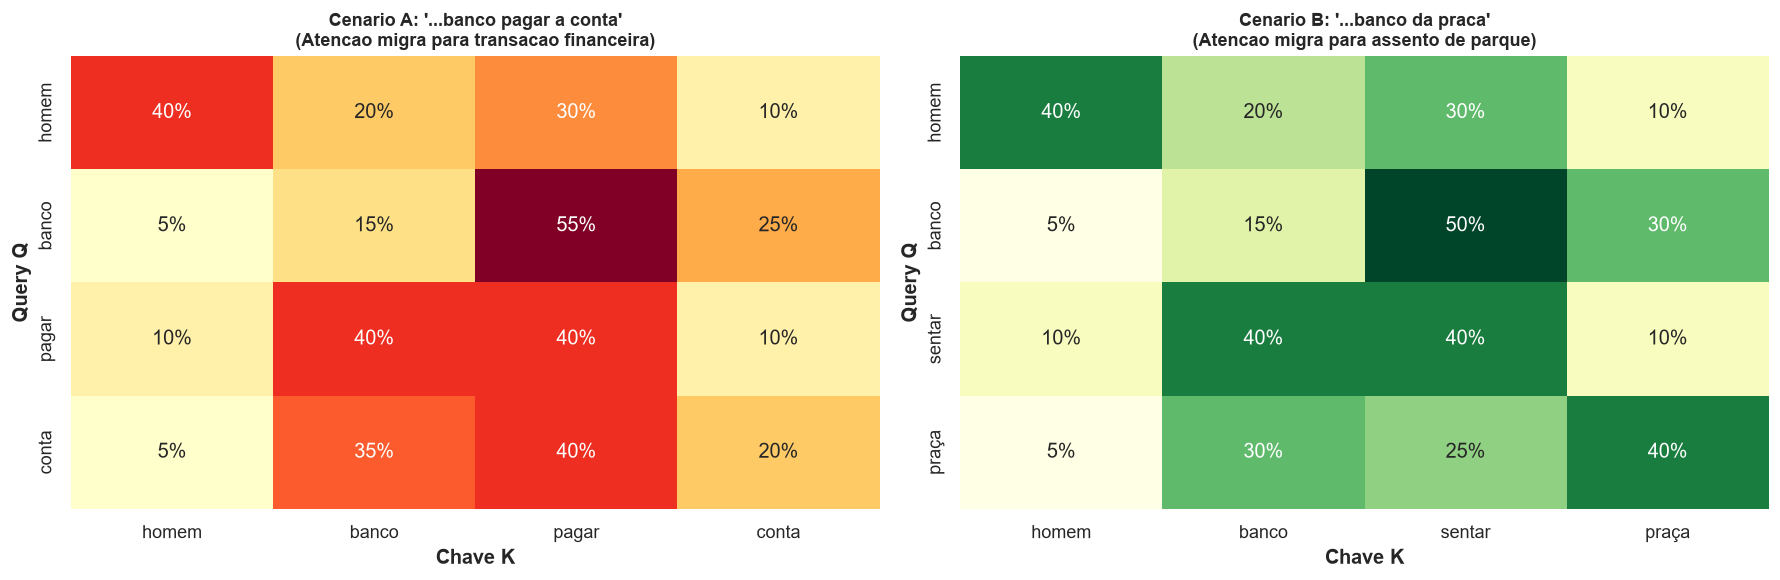

In [8]:
tokens_A = ["homem", "banco", "pagar", "conta"]
tokens_B = ["homem", "banco", "sentar", "praça"]

atencao_A = np.array([
    [0.40, 0.20, 0.30, 0.10],
    [0.05, 0.15, 0.55, 0.25], # "banco" olha 55% para pagar e 25% para conta!
    [0.10, 0.40, 0.40, 0.10],
    [0.05, 0.35, 0.40, 0.20]
])

atencao_B = np.array([
    [0.40, 0.20, 0.30, 0.10],
    [0.05, 0.15, 0.50, 0.30], # "banco" olha 50% para sentar e 30% para praça!
    [0.10, 0.40, 0.40, 0.10],
    [0.05, 0.30, 0.25, 0.40]
])

fig, eixos = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(atencao_A, annot=True, fmt=".0%", cmap="YlOrRd", 
            xticklabels=tokens_A, yticklabels=tokens_A, cbar=False, ax=eixos[0])
eixos[0].set_title("Cenario A: '...banco pagar a conta'\n(Atencao migra para transacao financeira)", fontsize=11, fontweight='bold')
eixos[0].set_xlabel("Chave K", fontweight='bold')
eixos[0].set_ylabel("Query Q", fontweight='bold')

sns.heatmap(atencao_B, annot=True, fmt=".0%", cmap="YlGn", 
            xticklabels=tokens_B, yticklabels=tokens_B, cbar=False, ax=eixos[1])
eixos[1].set_title("Cenario B: '...banco da praca'\n(Atencao migra para assento de parque)", fontsize=11, fontweight='bold')
eixos[1].set_xlabel("Chave K", fontweight='bold')
eixos[1].set_ylabel("Query Q", fontweight='bold')
plt.tight_layout()
plt.show()


---
## 📝 9. Desafio Prático: "Calculando na Mão com Papel e Lápis!"

**Sim, você consegue calcular toda a atenção dos Transformers na mão em 3 minutos!**  
Vamos fazer um exemplo simples com apenas **2 palavras** e vetores de tamanho **$d_k = 2$**.

### O Cenário do Nosso Exercício:
Frase: `["sol", "mar"]`

Nossos vetores simples:
* **Query ($Q$):**
  * Palavra 1 (`"sol"`): $Q_1 = [1, \; 0]$
  * Palavra 2 (`"mar"`): $Q_2 = [0, \; 1]$
* **Key ($K$):**
  * Palavra 1 (`"sol"`): $K_1 = [1, \; 0]$
  * Palavra 2 (`"mar"`): $K_2 = [0, \; 1]$
* **Value ($V$):**
  * Palavra 1 (`"sol"`): $V_1 = [10, \; 0]$ (representa calor)
  * Palavra 2 (`"mar"`): $V_2 = [0, \; 20]$ (representa água)

---

### Passo 1: Multiplicação $Q \cdot K^T$ (Afinidades)
Vamos calcular a nota de afinidade da palavra 1 (`"sol"`):
* Afinidade de `"sol"` com `"sol"`: $(1 \times 1) + (0 \times 0) = \mathbf{1}$
* Afinidade de `"sol"` com `"mar"`: $(1 \times 0) + (0 \times 1) = \mathbf{0}$
* **Linha 1 de notas:** $[1, \; 0]$

---

### Passo 2: Dividir por $\sqrt{d_k}$
Como $d_k = 1$ no nosso caso simplificado, $\sqrt{1} = 1$.  
As notas continuam: $[1, \; 0]$.

---

### Passo 3: O Softmax na Mão
1. Calculamos o exponencial $e^x$:
   * $e^1 \approx 2.71$
   * $e^0 = 1.00$
2. Somamos os dois:
   * $\text{Soma} = 2.71 + 1.00 = 3.71$
3. Dividimos pela soma para achar as porcentagens:
   * $\text{Atenção no "sol"} = 2.71 / 3.71 \approx \mathbf{0.73}$ ($73\%$)
   * $\text{Atenção no "mar"} = 1.00 / 3.71 \approx \mathbf{0.27}$ ($27\%$)

---

### Passo 4: Multiplicar por $V$ (A Mistura Final)
$$\text{Novo Sentido de "sol"} = (0.73 \times V_{\text{sol}}) + (0.27 \times V_{\text{mar}})$$
$$\text{Novo Sentido de "sol"} = (0.73 \times [10, \; 0]) + (0.27 \times [0, \; 20])$$
$$\text{Novo Sentido de "sol"} = [7.3, \; 0] + [0, \; 5.4] = \mathbf{[7.3, \; 5.4]}$$

✨ **Pronto! Você acabou de executar na mão todo o algoritmo dos Transformers!**  
O novo vetor do `"sol"` agora tem calor ($7.3$) e um toque do frescor do `"mar"` ($5.4$)!

Vamos validar essa conta com o código abaixo:


In [9]:
# Validação matemática do exercício de papel e lápis
q_exercicio = torch.tensor([[1.0, 0.0], [0.0, 1.0]])
k_exercicio = torch.tensor([[1.0, 0.0], [0.0, 1.0]])
v_exercicio = torch.tensor([[10.0, 0.0], [0.0, 20.0]])

# Executamos a fórmula canônica completa
scores = torch.matmul(q_exercicio, k_exercicio.T) / math.sqrt(1)
atencao = F.softmax(scores, dim=-1)
saida = torch.matmul(atencao, v_exercicio)

print("=== RESULTADO DO CÁLCULO NO PYTORCH ===")
print(f"Pesos de Atenção para 'sol': {atencao[0].numpy().round(2)} -> 73% em sol, 27% em mar")
print(f"Novo Vetor de 'sol': {saida[0].numpy().round(2)} -> Exatamente [7.3, 5.4]!")
print("[OK] A conta feita na mao bateu 100% com o codigo!")


=== RESULTADO DO CÁLCULO NO PYTORCH ===
Pesos de Atenção para 'sol': [0.73 0.27] -> 73% em sol, 27% em mar
Novo Vetor de 'sol': [7.31 5.38] -> Exatamente [7.3, 5.4]!
[OK] A conta feita na mao bateu 100% com o codigo!


---
## 📋 10. Tabela-Resumo de Consulta Rápida

| Símbolo | Nome | Metáfora Visual | O que faz na prática? |
| :--- | :--- | :--- | :--- |
| **$Q$** | **Query** | 📢 O Megafone da Palavra | Faz a pergunta: *"O que eu preciso para entender meu sentido?"* |
| **$K$** | **Key** | 🏷️ O Crachá no Peito | Exibe o anúncio: *"Quem sou eu e sobre o que eu falo."* |
| **$Q \cdot K^T$** | **Produto Escalar** | 🤝 O Teste de Afinidade | Cruza todas as perguntas com todos os crachás gerando uma nota. |
| **$\div \sqrt{d_k}$** | **Escalonamento** | 🎛️ O Regulador de Volume | Abaixa notas gigantes para o Softmax não ficar cego e travar. |
| **$\text{Softmax}$** | **Normalização** | 🍕 Fatias da Pizza (100%) | Converte as notas em porcentagens de atenção que somam 1.0. |
| **$V$** | **Value** | 🎒 A Mochila de Conteúdo | O significado semântico real que a palavra doa às outras. |
| **$\text{Softmax} \times V$** | **Saída Final** | 🎨 A Mistura de Tintas | Monta o novo vetor rico e contextualizado de cada palavra! |

---

## 🏆 Mensagem Final de Conquista
Você desmistificou por completo a equação mais importante da Inteligência Artificial do século XXI.  
Sempre que bater qualquer dúvida, volte a este notebook e lembre-se: a IA nada mais é do que palavras conversando numa sala com perguntas ($Q$), crachás ($K$) e mochilas ($V$)! 🚀


Essa é uma pergunta muito profunda e bonita sobre a própria natureza da matemática! 🌌

A resposta matemática para isso é: **não, para essa função específica, não pode existir outro número, porque o $e$ é único por definição lógica.**

Vamos entender o porquê de forma bem intuitiva:

---

### 1. O $e$ não foi "inventado", ele é uma consequência lógica 📐

Assim como o **$\pi \approx 3{,}14$** é o único número possível que resulta da divisão entre o perímetro de qualquer círculo e o seu diâmetro, o **$e \approx 2{,}718$** é o **único número do universo** com a seguinte propriedade:

$$\text{A taxa de crescimento da curva } f(x) = e^x \text{ no ponto zero é exatamente igual a } \mathbf{1}$$

Se você escolher qualquer número um milímetro maior (ex: $2{,}719$) ou um milímetro menor (ex: $2{,}717$), essa propriedade matemática perfeita se quebra. É uma verdade demonstrada por teoremas matemáticos rigorosos.

---

### 2. O que a ciência AINDA descobre hoje em dia? 🚀

Embora o número $e$ seja uma constante fixa e imutável, o que os cientistas continuam descobrindo são **novas fórmulas e funções** que usam o $e$ de maneiras diferentes!

Na Inteligência Artificial, por exemplo:
* Nos anos 1990, usavam a função **Sigmoid**.
* Em 2017, popularizaram o **Softmax**.
* Mais recentemente, criaram funções como **GELU** e **Swish** (usadas no GPT-4 e LLaMA), que misturam o $e$ com outras operações matemáticas para fazer os modelos pensarem ainda melhor.

---

> 💡 **Em resumo:**  
> O número $e$ é como uma peça fundamental e única da física e da matemática. Mas a forma como combinamos essas peças para criar algoritmos de Inteligência Artificial ainda está cheia de novas descobertas esperando para acontecer!